In [1]:
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
np.set_printoptions(precision=4)

In [2]:
import sys
sys.path.append("/home/vlew/CQCParse")

In [10]:
# from CQCParse.parsing import GaussianDataParser
# from CQCParse.relay import DataVault

from wilson.parsing import GaussianDataParser
from wilson.relay import DataVault

In [4]:
from wilson import spectrum
from wilson import rendering
from wilson import analysis

from wilson.utils import get_package_root

In [5]:
wilson_root = get_package_root()
data_vault = DataVault(wilson_root+'/tests/test_database/mini_files_database.csv')

dataframe_gaussian = data_vault.getting_files_DB("gaussian")
method_basis = dataframe_gaussian[(dataframe_gaussian['code'] == 'ACAC') & (dataframe_gaussian['method'] != 'PBE0')][["code", "method", "basis_set"]]
tuples_method_basis = [(row['code'], row['method'], row['basis_set']) for index, row in method_basis.iterrows()]
tuples_method_basis

[('ACAC', 'B3LYP', 'cc_pVQZ')]

In [17]:
log10=True
w1mw2=False
broad_factor_rc=10.

# terms_selection = [0, 1], [0, 1, 2, 3, 4, 5]
terms_selection = [0], [] # make a dictionary

regions = {1: ((1282., 1457., 10.), (2589., 3051., 10.)),
           6: ((500., 3150., 10.), (500., 6050., 10.))}

# template
settings_here = {'electrical': [0], 'mechanical': [],
                 'Gamma_rc': broad_factor_rc, 'region': 1,
                 'font_dict': {'size': 18}, 'figsize': (12, 15), 'norm_max': 1e12, 'norm_min': 1e7,
                 'dynamic_range_n': 30}

# spectra_dict = {"software": [], "code": [], "method": [], "basis_set": [],
#                 "el+mech max": [], "el max": [], "mech max": []}

region = 1
omega1 = np.arange(*regions[region][0])
omega2 = np.arange(*regions[region][1])

vibEL = False
datain = data_vault.make_DatainputDict('gaussian', ('ACAC', 'B3LYP', 'cc_pVQZ'), wilson_root)

computedSpectrum = spectrum.SpectrumEVV(omega1, omega2, input_data_info=datain, vib_levels_harmonic=vibEL)
computedSpectrum.load_data(GaussianDataParser)
computedSpectrum.addTerms(*terms_selection)

print(computedSpectrum.fundamentals)
print(sorted(list(computedSpectrum.fundamentals.values())))
print(sorted(list(computedSpectrum.fundamentals_harmonic.values())))
# computedSpectrum.fundamentals_harmonic.values()


Used vibrational energy levels are harmonic? - False
{'0': 3560.764, '1': 3014.192, '2': 2955.502, '3': 1786.815, '4': 1436.403, '5': 1372.251, '6': 1324.394, '7': 1164.166, '8': 975.352, '9': 840.892, '10': 578.825, '11': 424.861, '12': 2966.938, '13': 1438.853, '14': 1049.419, '15': 645.672, '16': 533.342, '17': 51.769}
[51.769, 424.861, 533.342, 578.825, 645.672, 840.892, 975.352, 1049.419, 1164.166, 1324.394, 1372.251, 1436.403, 1438.853, 1786.815, 2955.502, 2966.938, 3014.192, 3560.764]
[75.182, 424.945, 546.973, 586.481, 666.778, 858.703, 999.249, 1070.601, 1203.019, 1339.071, 1409.644, 1473.063, 1478.573, 1819.014, 3050.847, 3107.945, 3158.837, 3745.028]


In [18]:
region = settings_here['region']
Gamma_rc = settings_here['Gamma_rc']
# el_bool = settings_here['electrical']
# mech_bool = settings_here['mechanical']

sec_hypol_data = 0
if settings_here['electrical']:
    electrical, Qab_contrib_dict = computedSpectrum.intensity_electrical(Gamma_rc)
    sec_hypol_data += electrical

if settings_here['mechanical']:
    mechall, Qabc_contrib_dict = computedSpectrum.intensity_mechanical(Gamma_rc)
    # template_array = np.full(mechall.shape, -0.+0.j, dtype=complex)
    sec_hypol_data += mechall

0/324 modes combinations -- 0.0%
100/324 modes combinations -- 30.864197530864196%
200/324 modes combinations -- 61.72839506172839%
300/324 modes combinations -- 92.5925925925926%
Execution time -| electrical: 0.06629395484924316 seconds
Electrical anharmonicities are calculated


In [19]:
abs(sec_hypol_data) ** 2

array([[1.0978543245731577e-09, 1.0978543324227243e-09, 1.0978543402267108e-09, 1.0978543479851084e-09, 1.0978543556979239e-09, 1.0978543633651592e-09, 1.0978543709868098e-09, 1.0978543785628758e-09, 1.0978543860933616e-09, 1.0978543935782611e-09,
        1.0978544010175786e-09, 1.0978544084113170e-09, 1.0978544157594672e-09, 1.0978544230620362e-09, 1.0978544303190229e-09, 1.0978544375304227e-09, 1.0978544446962433e-09, 1.0978544518164802e-09, 1.0978544588911267e-09, 1.0978544659201981e-09,
        1.0978544729036862e-09, 1.0978544798415858e-09, 1.0978544867339072e-09, 1.0978544935806457e-09, 1.0978545003817983e-09, 1.0978545071373671e-09, 1.0978545138473557e-09, 1.0978545205117603e-09, 1.0978545271305783e-09, 1.0978545337038137e-09,
        1.0978545402314731e-09, 1.0978545467135406e-09, 1.0978545531500290e-09, 1.0978545595409356e-09, 1.0978545658862558e-09, 1.0978545721859931e-09, 1.0978545784401469e-09, 1.0978545846487193e-09, 1.0978545908117068e-09, 1.0978545969291146e-09,
        

In [8]:
np.max(abs(sec_hypol_data) ** 2)

1.0978558489972045e-09


self.intensities.max()==np.max(self.intensities.flatten(), axis=0): True 7.3397e-06


/home/vlew/Wilson/wilson/rendering/matplotlib_img.py:74: UserWarning: Log scale: values of z <= 0 have been masked
  cont = plt.contourf(self.X, self.Y, self.intensities,


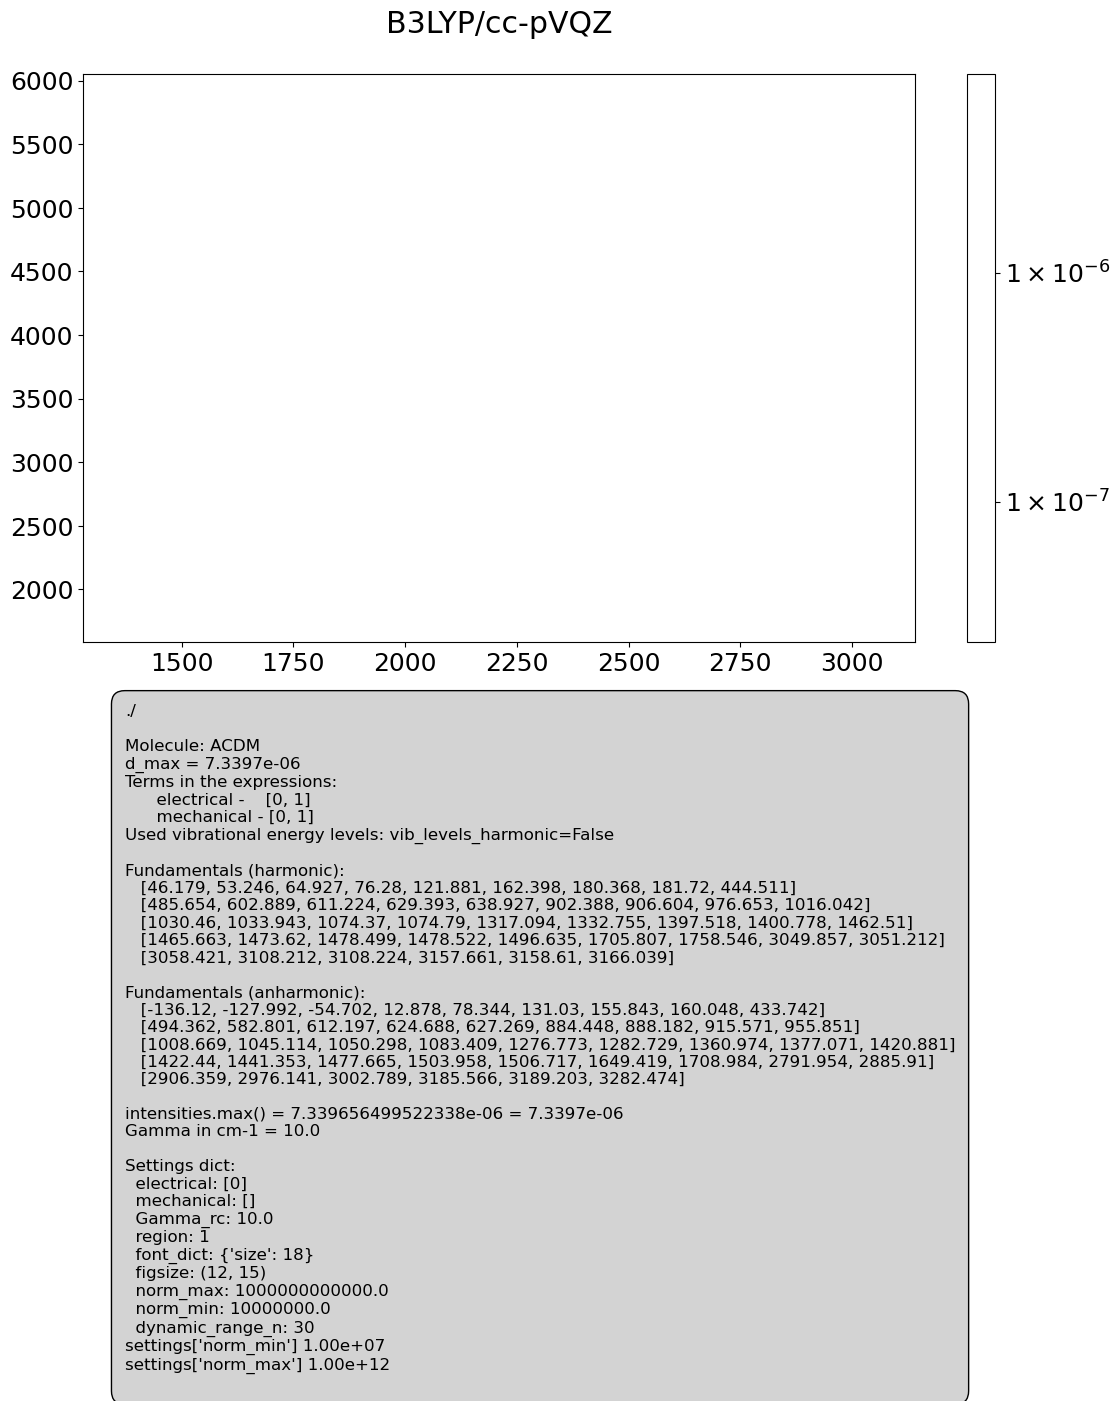

In [17]:
import os
directory='./'
other = {'regions': regions, 'terms_selection': terms_selection, 'w1mw2': False, 'log10': True}

name = rendering.make_name(datain, vibEL, settings_here, other, directory)
artist = rendering.SpectrumFigure(sec_hypol_data, computedSpectrum.w1_mesh, computedSpectrum.w2_mesh, settings_here)
title_on_top, text_under_the_figure = rendering.make_texts4fig(datain, computedSpectrum, artist, settings_here, other, directory)
fig = artist.plot2Dmatplotlib(nametuple=(name, os.path.join(os.path.dirname('__file__')), title_on_top),
                                text_under_the_figure=text_under_the_figure, diagonal=False, to_save=False)
plt.show()

In [7]:
log10=True
w1mw2=False
broad_factor_rc=10.

# terms_selection = [0, 1], [0, 1, 2, 3, 4, 5]
terms_selection = [0], [] # make a dictionary

regions = {1: ((1280., 3350., 10.), (2589., 6050., 10.)),
           6: ((500., 3150., 10.), (500., 6050., 10.))}

# template
settings_here = {'electrical': [0], 'mechanical': [],
                 'Gamma_rc': broad_factor_rc, 'region': 1,
                 'font_dict': {'size': 18}, 'figsize': (12, 15), 'norm_max': 1e12, 'norm_min': 1e7,
                 'dynamic_range_n': 30}

# spectra_dict = {"software": [], "code": [], "method": [], "basis_set": [],
#                 "el+mech max": [], "el max": [], "mech max": []}

region = 1
omega1 = np.arange(*regions[region][0])
omega2 = np.arange(*regions[region][1])

vibEL = False
datain = data_vault.make_DatainputDict('gaussian', ('ACAC', 'B3LYP', 'cc_pVQZ'), wilson_root)

computedSpectrum = spectrum.SpectrumEVV(omega1, omega2, input_data_info=datain, vib_levels_harmonic=vibEL)
computedSpectrum.load_data(GaussianDataParser)
computedSpectrum.addTerms(*terms_selection)

print(computedSpectrum.fundamentals)
print(sorted(list(computedSpectrum.fundamentals.values())))
print(sorted(list(computedSpectrum.fundamentals_harmonic.values())))
# computedSpectrum.fundamentals_harmonic.values()


Used vibrational energy levels are harmonic? - False
{'0': 2885.91, '1': 3185.566, '2': 3002.789, '3': 3282.474, '4': 2976.141, '5': 2791.954, '6': 3189.203, '7': 2906.359, '8': 1708.984, '9': 1649.419, '10': 1503.958, '11': 1477.665, '12': 1441.353, '13': 1506.717, '14': 1422.44, '15': 1420.881, '16': 1377.071, '17': 1360.974, '18': 1282.729, '19': 1276.773, '20': 1083.409, '21': 1045.114, '22': 1050.298, '23': 1008.669, '24': 955.851, '25': 915.571, '26': 888.182, '27': 884.448, '28': 624.688, '29': 612.197, '30': 627.269, '31': 582.801, '32': 494.362, '33': 433.742, '34': 160.048, '35': 155.843, '36': 131.03, '37': 78.344, '38': 12.878, '39': -54.702, '40': -127.992, '41': -136.12}
[-136.12, -127.992, -54.702, 12.878, 78.344, 131.03, 155.843, 160.048, 433.742, 494.362, 582.801, 612.197, 624.688, 627.269, 884.448, 888.182, 915.571, 955.851, 1008.669, 1045.114, 1050.298, 1083.409, 1276.773, 1282.729, 1360.974, 1377.071, 1420.881, 1422.44, 1441.353, 1477.665, 1503.958, 1506.717, 1649.

In [8]:
region = settings_here['region']
Gamma_rc = settings_here['Gamma_rc']
# el_bool = settings_here['electrical']
# mech_bool = settings_here['mechanical']

sec_hypol_data = 0
if settings_here['electrical']:
    electrical, Qab_contrib_dict = computedSpectrum.intensity_electrical(Gamma_rc)
    sec_hypol_data += electrical

if settings_here['mechanical']:
    mechall, Qabc_contrib_dict = computedSpectrum.intensity_mechanical(Gamma_rc)
    # template_array = np.full(mechall.shape, -0.+0.j, dtype=complex)
    sec_hypol_data += mechall

0/1764 modes combinations -- 0.0%
100/1764 modes combinations -- 5.668934240362812%
200/1764 modes combinations -- 11.337868480725623%
300/1764 modes combinations -- 17.006802721088434%
400/1764 modes combinations -- 22.675736961451246%
500/1764 modes combinations -- 28.34467120181406%
600/1764 modes combinations -- 34.01360544217687%
700/1764 modes combinations -- 39.682539682539684%
800/1764 modes combinations -- 45.35147392290249%
900/1764 modes combinations -- 51.02040816326531%
1000/1764 modes combinations -- 56.68934240362812%
1100/1764 modes combinations -- 62.358276643990926%
1200/1764 modes combinations -- 68.02721088435374%
1300/1764 modes combinations -- 73.69614512471655%
1400/1764 modes combinations -- 79.36507936507937%
1500/1764 modes combinations -- 85.03401360544218%
1600/1764 modes combinations -- 90.70294784580499%
1700/1764 modes combinations -- 96.3718820861678%
Execution time -| electrical: 17.055416584014893 seconds
Electrical anharmonicities are calculated


In [24]:
np.max(abs(sec_hypol_data) ** 2)

7.339657269721726e-06


self.intensities.max()==np.max(self.intensities.flatten(), axis=0): True 7.3397e-06


/home/vlew/Wilson/wilson/rendering/matplotlib_img.py:74: UserWarning: Log scale: values of z <= 0 have been masked
  cont = plt.contourf(self.X, self.Y, self.intensities,


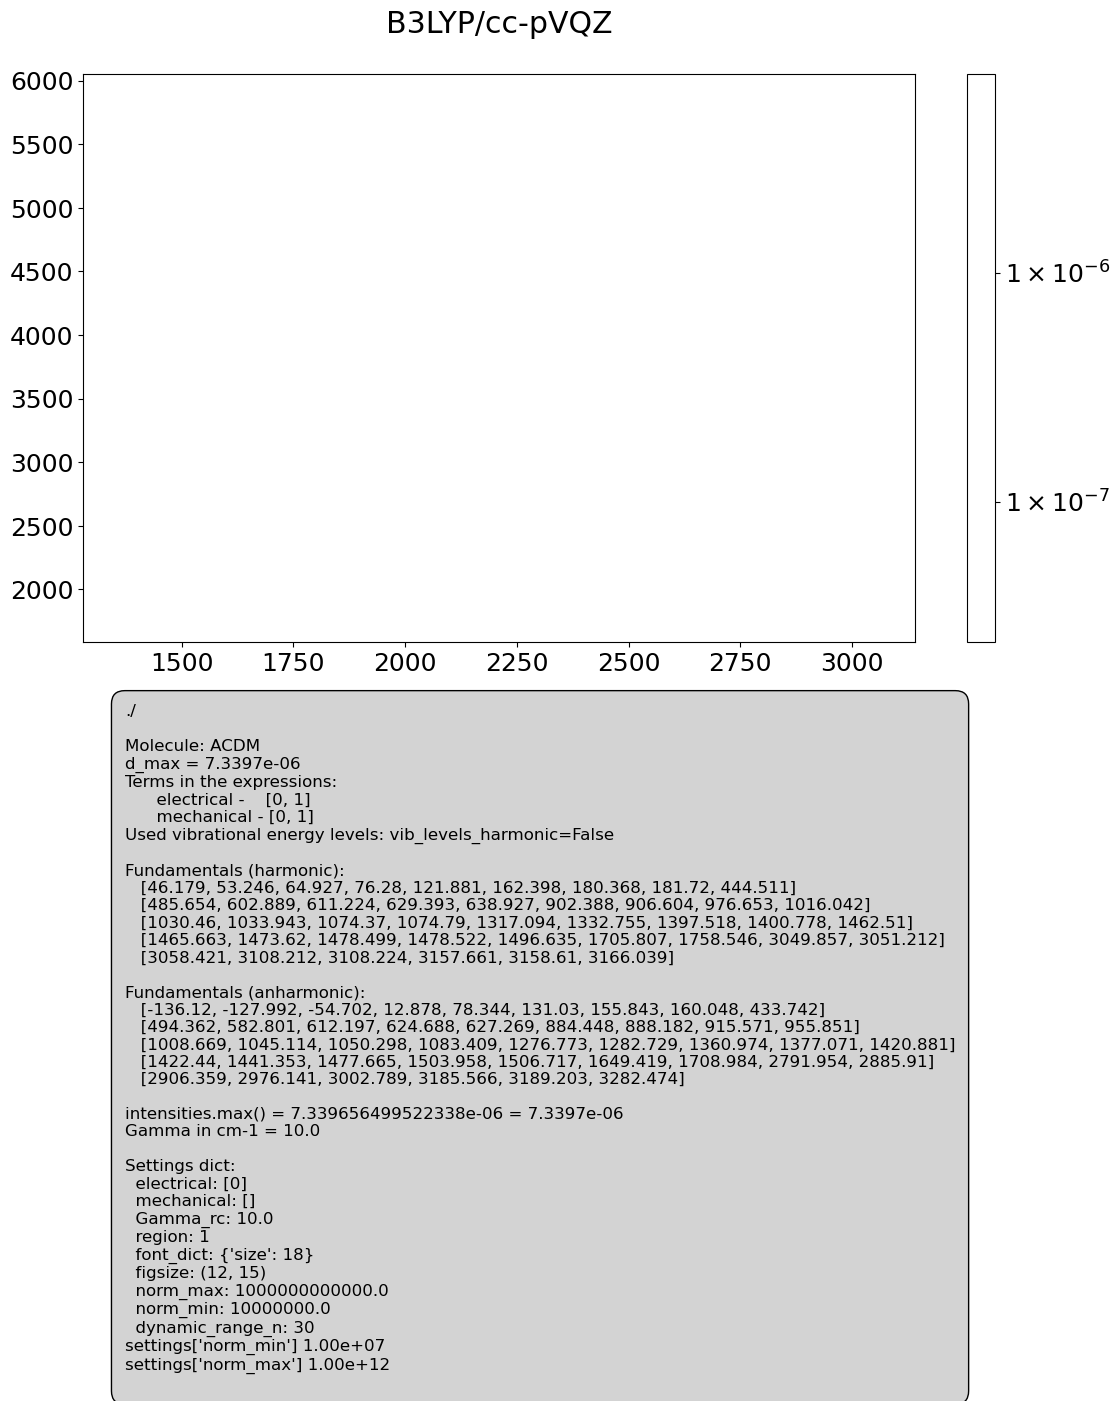

In [17]:
import os
directory='./'
other = {'regions': regions, 'terms_selection': terms_selection, 'w1mw2': False, 'log10': True}

name = rendering.make_name(datain, vibEL, settings_here, other, directory)
artist = rendering.SpectrumFigure(sec_hypol_data, computedSpectrum.w1_mesh, computedSpectrum.w2_mesh, settings_here)
title_on_top, text_under_the_figure = rendering.make_texts4fig(datain, computedSpectrum, artist, settings_here, other, directory)
fig = artist.plot2Dmatplotlib(nametuple=(name, os.path.join(os.path.dirname('__file__')), title_on_top),
                                text_under_the_figure=text_under_the_figure, diagonal=False, to_save=False)
plt.show()

# Resonances